# Figure 3: Semi-Synthetic Biological Validation

Validates phase transition theory using signal directions from real biological data (TCGA, PBMC).

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from multiprocessing import Pool
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from src import (
    ModelParams, whiten_to_identity, pls_svd, compute_overlaps,
    theoretical_overlaps, generate_semi_synthetic, apply_mcar
)

# ICML-compatible styling
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,  # TrueType fonts in PDF (avoids Type 3)
    'ps.fonttype': 42,   # TrueType fonts in PostScript
})

np.random.seed(42)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Load and Preprocess TCGA BRCA Data

In [2]:
import requests
import gzip

XENA_BASE = "https://tcga.xenahubs.net/download"
DATASETS = {
    "expr": "TCGA.BRCA.sampleMap/HiSeqV2.gz",
    "meth450": "TCGA.BRCA.sampleMap/HumanMethylation450.gz",
}

def download_xena_file(dataset_path: str, out_dir="../data/xena", chunk_size=1 << 20):
    os.makedirs(out_dir, exist_ok=True)
    url = f"{XENA_BASE}/{dataset_path}"
    local_path = os.path.join(out_dir, os.path.basename(dataset_path))
    if os.path.exists(local_path):
        print(f"[cached] {local_path}")
        return local_path
    print(f"[download] {url}")
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
    return local_path

def load_xena_matrix_gz(path_gz: str) -> pd.DataFrame:
    df = pd.read_csv(path_gz, sep="\t", index_col=0, compression="gzip")
    return df

# Download and load
expr_path = download_xena_file(DATASETS["expr"])
meth_path = download_xena_file(DATASETS["meth450"])

expr = load_xena_matrix_gz(expr_path)  # genes x samples
meth = load_xena_matrix_gz(meth_path)  # probes x samples

# Transpose to (samples x features)
X_raw = expr.T
Y_raw = meth.T

# Align samples
common_samples = X_raw.index.intersection(Y_raw.index)
X_raw = X_raw.loc[common_samples]
Y_raw = Y_raw.loc[common_samples]

print(f"TCGA BRCA: {len(common_samples)} paired samples")
print(f"  X (RNA): {X_raw.shape}")
print(f"  Y (Meth): {Y_raw.shape}")

[cached] ../data/xena/HiSeqV2.gz
[cached] ../data/xena/HumanMethylation450.gz
TCGA BRCA: 873 paired samples
  X (RNA): (873, 20530)
  Y (Meth): (873, 485577)


In [3]:
def preprocess_for_pls(X_df, Y_df, Dx=200, Dy=200):
    """
    Preprocess real data for PLS experiments:
    1. Select top-variance features
    2. Standardize
    3. PCA to target dimension
    4. Whiten to satisfy X^T X = N I
    """
    # Drop constant columns and NaNs
    X = X_df.dropna(axis=1).values.astype(np.float64)
    Y = Y_df.dropna(axis=1).values.astype(np.float64)
    
    # Standardize
    X = StandardScaler().fit_transform(X)
    Y = StandardScaler().fit_transform(Y)
    
    # PCA to reduce dimension
    pca_x = PCA(n_components=Dx)
    pca_y = PCA(n_components=Dy)
    X_pca = pca_x.fit_transform(X)
    Y_pca = pca_y.fit_transform(Y)
    
    # Whiten to satisfy X^T X = N I
    X_whitened = whiten_to_identity(X_pca)
    Y_whitened = whiten_to_identity(Y_pca)
    
    return X_whitened, Y_whitened

# Preprocess TCGA
Dx_tcga, Dy_tcga = 200, 200
X_tcga, Y_tcga = preprocess_for_pls(X_raw, Y_raw, Dx=Dx_tcga, Dy=Dy_tcga)
N_tcga = X_tcga.shape[0]

print(f"\nPreprocessed TCGA:")
print(f"  X_whitened: {X_tcga.shape}")
print(f"  Y_whitened: {Y_tcga.shape}")
print(f"  X^T X / N check: {np.linalg.norm(X_tcga.T @ X_tcga / N_tcga - np.eye(Dx_tcga)):.6f} (should be ~0)")


Preprocessed TCGA:
  X_whitened: (873, 200)
  Y_whitened: (873, 200)
  X^T X / N check: 0.000000 (should be ~0)


In [4]:
# Extract biological signal directions from complete TCGA data
u_tcga, v_tcga, sigma1_tcga = pls_svd(X_tcga, Y_tcga, prewhiten=False)  # Already whitened

print(f"\nExtracted biological signal directions (TCGA):")
print(f"  ||u_tcga|| = {np.linalg.norm(u_tcga):.6f}")
print(f"  ||v_tcga|| = {np.linalg.norm(v_tcga):.6f}")
print(f"  Top singular value σ₁ = {sigma1_tcga:.4f}")


Extracted biological signal directions (TCGA):
  ||u_tcga|| = 1.000000
  ||v_tcga|| = 1.000000
  Top singular value σ₁ = 0.9957


## 2. Load and Preprocess PBMC Multiome Data

In [5]:
# PBMC Multiome data from 10x Genomics
PBMC_URL = "https://cf.10xgenomics.com/samples/cell-arc/2.0.0/pbmc_granulocyte_sorted_10k/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5"
pbmc_dir = "../data/pbmc_multiome_10k"
pbmc_path = os.path.join(pbmc_dir, "pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5")

def download_pbmc_data():
    """Download PBMC Multiome 10k dataset from 10x Genomics."""
    os.makedirs(pbmc_dir, exist_ok=True)
    print(f"[download] {PBMC_URL}")
    with requests.get(PBMC_URL, stream=True) as r:
        r.raise_for_status()
        total_size = int(r.headers.get('content-length', 0))
        with open(pbmc_path, 'wb') as f:
            downloaded = 0
            for chunk in r.iter_content(chunk_size=1 << 20):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total_size > 0:
                        pct = 100 * downloaded / total_size
                        print(f"\r  Progress: {pct:.1f}%", end="", flush=True)
        print()
    print(f"[saved] {pbmc_path}")

if os.path.exists(pbmc_path):
    print(f"[cached] {pbmc_path}")
else:
    download_pbmc_data()

[cached] ../data/pbmc_multiome_10k/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5


In [6]:
import muon as mu
import scanpy as sc

# Load multiome data
mdata = mu.read_10x_h5(pbmc_path)

# Separate modalities
rna = mdata.mod['Gene Expression'] if 'Gene Expression' in mdata.mod else mdata.mod['rna']
atac = mdata.mod['Peaks'] if 'Peaks' in mdata.mod else mdata.mod['atac']

print(f"\nPBMC Multiome loaded:")
print(f"  RNA: {rna.shape}")
print(f"  ATAC: {atac.shape}")

# Basic preprocessing
sc.pp.filter_cells(rna, min_genes=200)
sc.pp.filter_genes(rna, min_cells=3)
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
rna = rna[:, rna.var['highly_variable']]

# ATAC: TF-IDF + LSI
sc.pp.filter_cells(atac, min_genes=200)
sc.pp.filter_genes(atac, min_cells=3)

# Subsample and align
common_cells = rna.obs_names.intersection(atac.obs_names)
n_subsample = min(5000, len(common_cells))
np.random.seed(42)
selected_cells = np.random.choice(common_cells, size=n_subsample, replace=False)

X_pbmc_raw = rna[selected_cells].X.toarray() if hasattr(rna[selected_cells].X, 'toarray') else rna[selected_cells].X
Y_pbmc_raw = atac[selected_cells].X.toarray() if hasattr(atac[selected_cells].X, 'toarray') else atac[selected_cells].X

# PCA + whitening
Dx_pbmc, Dy_pbmc = 200, 200
X_pbmc_raw = StandardScaler().fit_transform(X_pbmc_raw)
Y_pbmc_raw = StandardScaler().fit_transform(Y_pbmc_raw[:, :5000])  # Limit ATAC features

pca_x = PCA(n_components=Dx_pbmc)
pca_y = PCA(n_components=Dy_pbmc)
X_pbmc = whiten_to_identity(pca_x.fit_transform(X_pbmc_raw))
Y_pbmc = whiten_to_identity(pca_y.fit_transform(Y_pbmc_raw))
N_pbmc = X_pbmc.shape[0]

# Extract biological directions
u_pbmc, v_pbmc, sigma1_pbmc = pls_svd(X_pbmc, Y_pbmc, prewhiten=False)

print(f"\nPreprocessed PBMC:")
print(f"  X_whitened: {X_pbmc.shape}")
print(f"  Y_whitened: {Y_pbmc.shape}")
print(f"  Top singular value σ₁ = {sigma1_pbmc:.4f}")

ModuleNotFoundError: No module named 'muon'

## 3. Run Semi-Synthetic Experiments

In [ ]:
def run_semi_synthetic_experiment(
    X_whitened, u0, v0, N, Dx, Dy,
    theta_values, m_values, n_trials=500,
    experiment_name="dataset"
):
    """
    Run semi-synthetic validation for a single dataset.
    
    Returns results for:
    - Phase transition (theta sweep at m=0.3)
    - Missingness degradation (m sweep at theta=1.5*theta_crit)
    - Biological vs random comparison
    
    Stores raw trial values for flexible statistics computation (std, quantiles).
    """
    results = {
        'theta_sweep': [],
        'miss_sweep': [],
        'bio_vs_random': [],
    }
    
    # Compute theta_crit for reference
    alpha_x = N / Dx
    alpha_y = N / Dy
    m_ref = 0.3
    rho_ref = (1 - m_ref) ** 2
    theta_crit = 1 / ((alpha_x * alpha_y) ** 0.25 * np.sqrt(rho_ref))
    
    print(f"\n{experiment_name}: N={N}, Dx={Dx}, Dy={Dy}")
    print(f"  θ_crit (m=0.3) = {theta_crit:.4f}")
    
    # --- Experiment A: Theta sweep at fixed missingness ---
    print(f"  Running theta sweep...")
    for theta in tqdm(theta_values, desc="  θ sweep"):
        rx2_bio, ry2_bio = [], []
        rx2_rand, ry2_rand = [], []
        
        for trial in range(n_trials):
            # Biological directions
            X, Y, Sx, Sy = generate_semi_synthetic(
                X_whitened, u0, v0, theta, m_ref, m_ref, Dy, seed=trial
            )
            u_hat, v_hat, _ = pls_svd(X, Y, prewhiten=True)
            rx2, ry2 = compute_overlaps(u_hat, v_hat, u0, v0)
            rx2_bio.append(rx2)
            ry2_bio.append(ry2)
            
            # Random directions (for comparison)
            np.random.seed(trial + 10000)
            u0_rand = np.random.randn(Dx)
            u0_rand /= np.linalg.norm(u0_rand)
            v0_rand = np.random.randn(Dy)
            v0_rand /= np.linalg.norm(v0_rand)
            
            X_r, Y_r, _, _ = generate_semi_synthetic(
                X_whitened, u0_rand, v0_rand, theta, m_ref, m_ref, Dy, seed=trial
            )
            u_hat_r, v_hat_r, _ = pls_svd(X_r, Y_r, prewhiten=True)
            rx2_r, ry2_r = compute_overlaps(u_hat_r, v_hat_r, u0_rand, v0_rand)
            rx2_rand.append(rx2_r)
            ry2_rand.append(ry2_r)
        
        # Theoretical prediction
        params = ModelParams(N=N, Dx=Dx, Dy=Dy, theta=theta, mx=m_ref, my=m_ref)
        rx2_theory, ry2_theory = theoretical_overlaps(params)
        
        # Store raw trial values for flexible statistics
        results['theta_sweep'].append({
            'theta': theta,
            'theta_norm': theta / theta_crit,
            'Rx2_bio': np.array(rx2_bio),
            'Ry2_bio': np.array(ry2_bio),
            'Rx2_rand': np.array(rx2_rand),
            'Ry2_rand': np.array(ry2_rand),
            'Rx2_theory': rx2_theory,
            'Ry2_theory': ry2_theory,
        })
    
    # --- Experiment B: Missingness sweep at fixed theta ---
    theta_fixed = 1.5 * theta_crit
    print(f"  Running missingness sweep at θ={theta_fixed:.3f}...")
    
    for m in tqdm(m_values, desc="  m sweep"):
        rx2_list, ry2_list = [], []
        
        for trial in range(n_trials):
            X, Y, Sx, Sy = generate_semi_synthetic(
                X_whitened, u0, v0, theta_fixed, m, m, Dy, seed=trial
            )
            u_hat, v_hat, _ = pls_svd(X, Y, prewhiten=True)
            rx2, ry2 = compute_overlaps(u_hat, v_hat, u0, v0)
            rx2_list.append(rx2)
            ry2_list.append(ry2)
        
        # Theoretical prediction
        params = ModelParams(N=N, Dx=Dx, Dy=Dy, theta=theta_fixed, mx=m, my=m)
        rx2_theory, ry2_theory = theoretical_overlaps(params)
        
        # Store raw trial values for flexible statistics
        results['miss_sweep'].append({
            'm': m,
            'rho': (1 - m) ** 2,
            'Rx2': np.array(rx2_list),
            'Ry2': np.array(ry2_list),
            'Rx2_theory': rx2_theory,
            'Ry2_theory': ry2_theory,
        })
    
    results['theta_crit'] = theta_crit
    results['N'] = N
    results['Dx'] = Dx
    results['Dy'] = Dy
    
    return results

In [ ]:
# Define parameter grids
n_trials = 500
m_ref = 0.3
rho_ref = (1 - m_ref) ** 2

# Compute theta_crit for each dataset
alpha_x_tcga = N_tcga / Dx_tcga
alpha_y_tcga = N_tcga / Dy_tcga
theta_crit_tcga = 1 / ((alpha_x_tcga * alpha_y_tcga) ** 0.25 * np.sqrt(rho_ref))

alpha_x_pbmc = N_pbmc / Dx_pbmc
alpha_y_pbmc = N_pbmc / Dy_pbmc
theta_crit_pbmc = 1 / ((alpha_x_pbmc * alpha_y_pbmc) ** 0.25 * np.sqrt(rho_ref))

# Create dataset-specific theta values (each spanning 0.5 to 2.5 of their own theta_crit)
theta_values_tcga = np.linspace(0.5 * theta_crit_tcga, 2.5 * theta_crit_tcga, 20)
theta_values_pbmc = np.linspace(0.5 * theta_crit_pbmc, 2.5 * theta_crit_pbmc, 20)

m_values = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])

print(f"TCGA: θ_crit = {theta_crit_tcga:.4f}, θ range: [{theta_values_tcga[0]:.3f}, {theta_values_tcga[-1]:.3f}]")
print(f"PBMC: θ_crit = {theta_crit_pbmc:.4f}, θ range: [{theta_values_pbmc[0]:.3f}, {theta_values_pbmc[-1]:.3f}]")
print(f"m values: {m_values}")

TCGA: θ_crit = 0.6838, θ range: [0.342, 1.709]
PBMC: θ_crit = 0.2857, θ range: [0.143, 0.714]
m values: [0.  0.1 0.2 0.3 0.4 0.5]


In [ ]:
# Check for cached results
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)
cache_file = os.path.join(results_dir, 'fig3_results.pkl')

if os.path.exists(cache_file):
    print("Loading cached results...")
    with open(cache_file, 'rb') as f:
        all_results = pickle.load(f)
    results_tcga = all_results['tcga']
    results_pbmc = all_results['pbmc']
    print("Done!")
else:
    print("Running experiments...")
    
    # Run TCGA experiments with TCGA-specific theta values
    results_tcga = run_semi_synthetic_experiment(
        X_tcga, u_tcga, v_tcga, N_tcga, Dx_tcga, Dy_tcga,
        theta_values_tcga, m_values, n_trials=n_trials,
        experiment_name="TCGA BRCA"
    )
    
    # Run PBMC experiments with PBMC-specific theta values
    results_pbmc = run_semi_synthetic_experiment(
        X_pbmc, u_pbmc, v_pbmc, N_pbmc, Dx_pbmc, Dy_pbmc,
        theta_values_pbmc, m_values, n_trials=n_trials,
        experiment_name="PBMC"
    )
    
    # Cache results
    all_results = {'tcga': results_tcga, 'pbmc': results_pbmc}
    with open(cache_file, 'wb') as f:
        pickle.dump(all_results, f)
    print("\nResults cached!")

Loading cached results...
Done!


## 4. Create Publication Figure

In [ ]:
def compute_stats(values):
    """Compute mean, std, and quantiles from raw trial values."""
    return {
        'mean': np.mean(values),
        'std': np.std(values),
        'q05': np.percentile(values, 5),
        'q95': np.percentile(values, 95),
    }

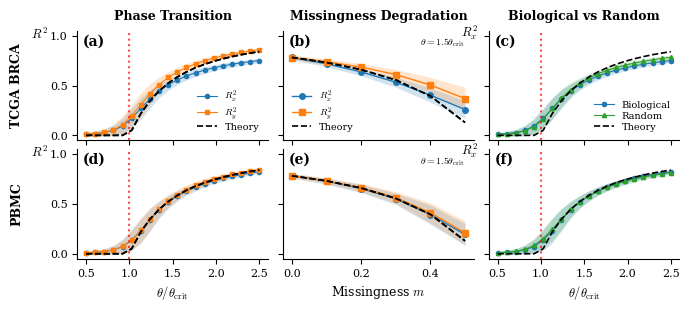


Figure saved: ../figures/fig3_biological_validation.pdf


In [ ]:
# Figure with ±std error bands
fig = plt.figure(figsize=(7.0, 3.0))

# Create gridspec with shared axes structure
gs = gridspec.GridSpec(2, 3, hspace=0.08, wspace=0.08,
                       left=0.12, right=0.98, bottom=0.12, top=0.88)

datasets = [
    ('TCGA BRCA', results_tcga),
    ('PBMC', results_pbmc),
]

# Column titles
col_titles = ['Phase Transition', 'Missingness Degradation', 'Biological vs Random']

# Store axes for sharing
axes = []

# Fixed x-axis range for theta_norm (both datasets now span 0.5 to 2.5)
xlim_theta = [0.4, 2.6]

for row, (name, results) in enumerate(datasets):
    ax_a = fig.add_subplot(gs[row, 0])
    ax_b = fig.add_subplot(gs[row, 1])
    ax_c = fig.add_subplot(gs[row, 2])
    axes.append([ax_a, ax_b, ax_c])
    
    theta_crit = results['theta_crit']
    
    # --- Panel A/D: Phase transition (θ sweep) ---
    theta_sweep = results['theta_sweep']
    theta_norm = [r['theta_norm'] for r in theta_sweep]
    
    # Compute stats from raw values
    rx2_bio_stats = [compute_stats(r['Rx2_bio']) for r in theta_sweep]
    ry2_bio_stats = [compute_stats(r['Ry2_bio']) for r in theta_sweep]
    rx2_rand_stats = [compute_stats(r['Rx2_rand']) for r in theta_sweep]
    ry2_rand_stats = [compute_stats(r['Ry2_rand']) for r in theta_sweep]
    
    # R_x² - biological
    ax_a.plot(theta_norm, [s['mean'] for s in rx2_bio_stats],
              'o-', markersize=3, linewidth=0.8, color='C0', label=r'$R_x^2$')
    ax_a.fill_between(theta_norm,
                      [s['mean'] - s['std'] for s in rx2_bio_stats],
                      [s['mean'] + s['std'] for s in rx2_bio_stats],
                      color='C0', alpha=0.2, linewidth=0)
    
    # R_y² - biological
    ax_a.plot(theta_norm, [s['mean'] for s in ry2_bio_stats],
              's-', markersize=3, linewidth=0.8, color='C1', label=r'$R_y^2$')
    ax_a.fill_between(theta_norm,
                      [s['mean'] - s['std'] for s in ry2_bio_stats],
                      [s['mean'] + s['std'] for s in ry2_bio_stats],
                      color='C1', alpha=0.2, linewidth=0)
    
    # Theory
    ax_a.plot(theta_norm, [r['Rx2_theory'] for r in theta_sweep],
              'k--', linewidth=1.2, label='Theory')
    ax_a.plot(theta_norm, [r['Ry2_theory'] for r in theta_sweep],
              'k--', linewidth=1.2)
    
    ax_a.axvline(1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
    ax_a.set_ylim([-0.05, 1.05])
    ax_a.set_xlim(xlim_theta)
    
    # --- Panel B/E: Missingness degradation ---
    miss_sweep = results['miss_sweep']
    m_vals = [r['m'] for r in miss_sweep]
    
    # Compute stats from raw values
    rx2_miss_stats = [compute_stats(r['Rx2']) for r in miss_sweep]
    ry2_miss_stats = [compute_stats(r['Ry2']) for r in miss_sweep]
    
    ax_b.plot(m_vals, [s['mean'] for s in rx2_miss_stats],
              'o-', markersize=4, linewidth=1, color='C0', label=r'$R_x^2$')
    ax_b.fill_between(m_vals,
                      [s['mean'] - s['std'] for s in rx2_miss_stats],
                      [s['mean'] + s['std'] for s in rx2_miss_stats],
                      color='C0', alpha=0.2, linewidth=0)
    
    ax_b.plot(m_vals, [s['mean'] for s in ry2_miss_stats],
              's-', markersize=4, linewidth=1, color='C1', label=r'$R_y^2$')
    ax_b.fill_between(m_vals,
                      [s['mean'] - s['std'] for s in ry2_miss_stats],
                      [s['mean'] + s['std'] for s in ry2_miss_stats],
                      color='C1', alpha=0.2, linewidth=0)
    
    ax_b.plot(m_vals, [r['Rx2_theory'] for r in miss_sweep],
              'k--', linewidth=1.2, label='Theory')
    ax_b.plot(m_vals, [r['Ry2_theory'] for r in miss_sweep],
              'k--', linewidth=1.2)
    
    ax_b.set_ylim([-0.05, 1.05])
    
    # Add theta annotation in upper right
    ax_b.text(0.95, 0.95, r'$\theta = 1.5\theta_{\mathrm{crit}}$',
              transform=ax_b.transAxes, fontsize=7, ha='right', va='top')
    
    # --- Panel C/F: Biological vs Random directions ---
    # Biological
    ax_c.plot(theta_norm, [s['mean'] for s in rx2_bio_stats],
              'o-', markersize=3, linewidth=0.8, color='C0', label='Biological')
    ax_c.fill_between(theta_norm,
                      [s['mean'] - s['std'] for s in rx2_bio_stats],
                      [s['mean'] + s['std'] for s in rx2_bio_stats],
                      color='C0', alpha=0.2, linewidth=0)
    
    # Random
    ax_c.plot(theta_norm, [s['mean'] for s in rx2_rand_stats],
              '^-', markersize=3, linewidth=0.8, color='C2', label='Random')
    ax_c.fill_between(theta_norm,
                      [s['mean'] - s['std'] for s in rx2_rand_stats],
                      [s['mean'] + s['std'] for s in rx2_rand_stats],
                      color='C2', alpha=0.2, linewidth=0)
    
    # Theory
    ax_c.plot(theta_norm, [r['Rx2_theory'] for r in theta_sweep],
              'k--', linewidth=1.2, label='Theory')
    
    ax_c.axvline(1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
    ax_c.set_ylim([-0.05, 1.05])
    ax_c.set_xlim(xlim_theta)
    
    # Dataset name on the left (rotated 90 degrees)
    ax_a.text(-0.32, 0.5, name, transform=ax_a.transAxes,
              fontsize=9, fontweight='bold', va='center', ha='center',
              rotation=90)
    
    # Handle x-axis labels (only bottom row)
    if row == 0:
        # Top row: no x-axis labels
        ax_a.tick_params(labelbottom=False)
        ax_b.tick_params(labelbottom=False)
        ax_c.tick_params(labelbottom=False)

        ax_a.legend(loc='lower right', # bbox_to_anchor=(0.5, -0.45),
                   ncol=1, frameon=False, fontsize=7, labelspacing=0.05)
        ax_b.legend(loc='lower left', # bbox_to_anchor=(0.5, -0.45),
                   ncol=1, frameon=False, fontsize=7, labelspacing=0.05)
        ax_c.legend(loc='lower right', # bbox_to_anchor=(0.5, -0.45),
                   ncol=1, frameon=False, fontsize=7, labelspacing=0.20)


    else:
        # Bottom row: add x-axis labels
        ax_a.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
        ax_b.set_xlabel(r'Missingness $m$')
        ax_c.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
    
    # Handle y-axis labels (only left column shows ticks)
    ax_b.tick_params(labelleft=False)
    ax_c.tick_params(labelleft=False)

# Add column titles at top
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=9, fontweight='bold', pad=8)

# Add y-axis labels rotated at top of y-axis for each column
# Column 1 (a/d): R²
axes[0][0].text(-0.20, 0.90, r'$R^2$', transform=axes[0][0].transAxes,
                fontsize=9, ha='center', va='bottom', rotation=0)
axes[1][0].text(-0.20, 0.90, r'$R^2$', transform=axes[1][0].transAxes,
                fontsize=9, ha='center', va='bottom', rotation=0)

# Column 3 (c/f): R_x²
axes[0][2].text(-0.10, 0.90, r'$R_x^2$', transform=axes[0][2].transAxes,
                fontsize=9, ha='center', va='bottom', rotation=0)
axes[1][2].text(-0.10, 0.90, r'$R_x^2$', transform=axes[1][2].transAxes,
                fontsize=9, ha='center', va='bottom', rotation=0)

# Add panel labels to the right of y-axis (inside plot area, top-left)
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for i, row_axes in enumerate(axes):
    for j, ax in enumerate(row_axes):
        label_idx = i * 3 + j
        ax.text(0.03, 0.97, labels[label_idx], transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='top', ha='left')

plt.savefig('../figures/fig3_biological_validation.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: ../figures/fig3_biological_validation.pdf")